# 220119 F2 run11: Behavior Decoding

Stage 3 for the restarted V2a workflow. This notebook first consumes the saved outputs from `cluster_clean_reconstruct.ipynb`: per-method cleaned traces and cluster-selection JSON files under `outputs/linear/v2a-RSNs/<data_name>/<method>/`. It then runs the two downstream behavior analyses on those chained artifacts:

1. supervised behavior decoding for tail vigor and bout state;
2. causal-state behavior decoding on the same raw and cleaned trace variants.

These chained analyses write descriptive downstream outputs to `outputs/behavior_decoding/v2a-RSNs/<data_name>/`. The final section optionally runs the strict fold-local evaluator into `outputs/evaluation/v2a-RSNs/<data_name>/`; that strict section intentionally refits preprocessing inside folds and is the leakage-safe path for primary manuscript claims.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists() and (path / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
print(f"Project root: {PROJECT_ROOT}")


import json

from ica_denoising.behavior_decoding import (
    TraceVariant,
    load_trace_variants,
    make_behavior_targets,
    plot_behavior_preservation_summary,
    plot_behavior_trace_evidence,
    run_decoding_experiment,
    summarize_trace_preservation,
)
from ica_denoising.bss_notebook import (
    BSS_METHODS,
    available_datasets,
    cleaned_trace_output_paths,
    cluster_selection_output_path,
    get_dataset,
    load_traces,
    output_directory,
)
from ica_denoising.causal_behavior_decoding import CausalStateConfig, fit_causal_state_model
from ica_denoising.evaluation_diagnostics import build_provenance_manifest
from ica_denoising.evaluation_runner import load_evaluation_config, run_dataset_evaluation


Project root: /Users/sadiqadedayo/Documents/projects/ICA/ica-denoising


## Configuration

`RUN_CHAINED_BEHAVIOR_DECODING` runs the stage-dependent analysis that loads outputs from `cluster_clean_reconstruct.ipynb`. `RUN_STRICT_EVALUATION` runs the fold-local evaluator after that; it is independent by design.

In [2]:
DATASET_KEY = "v2a-RSNs/220210_F1_run6_fluorescence"
METHODS_TO_RUN = list(BSS_METHODS)

RUN_CHAINED_BEHAVIOR_DECODING = True
RUN_STRICT_EVALUATION = True
STRICT_CONFIG_NAME = "evaluation.example.json"  # use evaluation.smoke.json for quick checks

BOUT_QUANTILE = 0.75
SMOOTH_WINDOW = 3
DECODER_LAGS = (0, 1, 2)
TARGET_SHIFT = 0
BEHAVIOR_N_SPLITS = 5
BEHAVIOR_GAP = 3
RIDGE_ALPHA = 10.0
NULL_BLOCK_SIZE = 60
RANDOM_STATE = 0
N_JOBS = 1

CAUSAL_WINDOW = 15
CAUSAL_TARGET_SHIFTS = (0,)
CAUSAL_LATENT_DIM = 3
CAUSAL_N_SPLITS = 5
CAUSAL_GAP = 14  # must be at least CAUSAL_WINDOW - 1
CAUSAL_RIDGE_ALPHA = 5.0

PLOT_DPI = 300

dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
OUTPUT_DATA_NAME = dataset.recording_id or dataset.data_name
CHAINED_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "behavior_decoding" / dataset.group / OUTPUT_DATA_NAME
CHAINED_FIGURE_DIR = CHAINED_OUTPUT_DIR / "figures"
STRICT_OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "evaluation"
STRICT_OUTPUT_DIR = STRICT_OUTPUT_ROOT / dataset.group / OUTPUT_DATA_NAME

print(f"Dataset: {dataset.key}")
print(f"Trace file: {dataset.trace_path.relative_to(PROJECT_ROOT)}")
print(f"Tail-angle file: {dataset.tail_angle_path.relative_to(PROJECT_ROOT) if dataset.tail_angle_path else None}")
print(f"Chained behavior output: {CHAINED_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"Strict evaluation output: {STRICT_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
build_provenance_manifest([dataset])


Dataset: v2a-RSNs/220210_F1_run6_fluorescence
Trace file: data/v2a-RSNs/220210_F1_run6/220210_F1_F1_run6_cells_fluorescence_signals.npy
Tail-angle file: data/v2a-RSNs/220210_F1_run6/220210_F1_F1_run6_tail_angle.npy
Chained behavior output: outputs/behavior_decoding/v2a-RSNs/220210_F1_run6
Strict evaluation output: outputs/evaluation/v2a-RSNs/220210_F1_run6


,dataset_key,recording_id,fish_id,run_id,modality,sample_rate_hz,trace_path,trace_exists,trace_sha256,trace_shape,...,trace_nonfinite_count,behavior_path,behavior_exists,behavior_sha256,behavior_shape,behavior_dtype,behavior_nonfinite_count,trace_duplicate_count,behavior_duplicate_count,provenance_warning
0,v2a-RSNs/220210_F1_run6_fluorescence,220210_F1_run6,220210_F1,run6,fluorescence,5.5573,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220210_F1_run6/220210_F1_F1_run6_cells_fluore...,True,49ebb33a03cbad62158d7421fbf0d87e62576ce4b5323c1ca144faa52bef411b,"[1085, 3334]",...,19530,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220210_F1_run6/220210_F1_F1_run6_tail_angle.npy,True,675acd006f5bb4cc16c0a2e5b4443b464c477db0dab4de9e9f4ff0f851e3df85,[179331],float64,0,1,1,


## Load Cluster-Cleaned Outputs

This cell is the explicit dependency on `cluster_clean_reconstruct.ipynb`. It requires the cleaned trace and cluster-selection JSON for each selected method.

In [3]:
def _relative(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def load_cluster_stage_inputs(dataset, methods):
    rows = []
    missing = []
    for method in methods:
        method_output_dir = output_directory(
            method,
            OUTPUT_DATA_NAME,
            PROJECT_ROOT,
            analysis_kind="linear",
            dataset_group=dataset.group,
        )
        cleaned_path = cleaned_trace_output_paths(dataset, method, method_output_dir)["cleaned"]
        selection_path = cluster_selection_output_path(dataset, method, method_output_dir)
        if not cleaned_path.exists() or not selection_path.exists():
            missing.append(
                {
                    "method": method,
                    "cleaned_exists": cleaned_path.exists(),
                    "selection_exists": selection_path.exists(),
                    "cleaned_path": _relative(cleaned_path),
                    "selection_path": _relative(selection_path),
                }
            )
            continue
        payload = json.loads(selection_path.read_text(encoding="utf-8"))
        rows.append(
            {
                "method": method,
                "cleaned_path": cleaned_path,
                "cluster_selection_path": selection_path,
                "accepted_clusters": payload.get("accepted_clusters", []),
                "rejected_clusters": payload.get("rejected_clusters", []),
                "accepted_components": payload.get("accepted_components", []),
                "rejected_components": payload.get("rejected_components", []),
                "keep_top_cluster_count": payload.get("keep_top_cluster_count"),
                "selection_scope": payload.get("selection_scope"),
                "n_clusters_observed": payload.get("n_clusters_observed"),
            }
        )
    if not rows:
        missing_table = pd.DataFrame(missing)
        raise FileNotFoundError(
            "No cluster-cleaned outputs were found. Run cluster_clean_reconstruct.ipynb first.\n"
            f"Missing outputs:\n{missing_table.to_string(index=False)}"
        )
    return pd.DataFrame(rows), pd.DataFrame(missing)


cluster_inputs, missing_cluster_inputs = load_cluster_stage_inputs(dataset, METHODS_TO_RUN)
if not missing_cluster_inputs.empty:
    display(missing_cluster_inputs)

cluster_inputs_display = cluster_inputs.copy()
for column in ["cleaned_path", "cluster_selection_path"]:
    cluster_inputs_display[column] = cluster_inputs_display[column].map(_relative)
cluster_inputs_display


,method,cleaned_exists,selection_exists,cleaned_path,selection_path
0,sobi,False,False,outputs/linear/v2a-RSNs/220210_F1_run6/sobi/cleaned/cleaned_sobi_220210_F1_run6_fluorescence.npy,outputs/linear/v2a-RSNs/220210_F1_run6/sobi/clusters/cluster_selection_sobi_220210_F1_run6_fluorescence.json
1,jade,False,False,outputs/linear/v2a-RSNs/220210_F1_run6/jade/cleaned/cleaned_jade_220210_F1_run6_fluorescence.npy,outputs/linear/v2a-RSNs/220210_F1_run6/jade/clusters/cluster_selection_jade_220210_F1_run6_fluorescence.json


,method,cleaned_path,cluster_selection_path,accepted_clusters,rejected_clusters,accepted_components,rejected_components,keep_top_cluster_count,selection_scope,n_clusters_observed
0,fastica,outputs/linear/v2a-RSNs/220210_F1_run6/fastica/cleaned/cleaned_fastica_220210_F1_run6_fluorescence.npy,outputs/linear/v2a-RSNs/220210_F1_run6/fastica/clusters/cluster_selection_fastica_220210_F1_run6_fluorescence.json,"[3, 1]","[0, 2, 4, 5, 6]","[14, 32, 34, 46, 74, 88, 99, 101, 106, 108, 114, 118, 123, 133, 142, 146, 156, 169, 181, 190, 227, 228, 235, 236, 23...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...",None,full_recording_descriptive,7
1,infomax,outputs/linear/v2a-RSNs/220210_F1_run6/infomax/cleaned/cleaned_infomax_220210_F1_run6_fluorescence.npy,outputs/linear/v2a-RSNs/220210_F1_run6/infomax/clusters/cluster_selection_infomax_220210_F1_run6_fluorescence.json,"[5, 6]","[0, 1, 2, 3, 4]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 3...","[31, 63, 70, 71, 72, 73, 75, 77, 78, 79, 80, 82, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100...",None,full_recording_descriptive,7


In [ ]:
all_variants = load_trace_variants(
    dataset.trace_path.parent,
    raw_name=dataset.trace_path.name,
    cleaned_root=cluster_inputs["cleaned_path"].iloc[0].parents[2],
    dataset_name=dataset.data_name,
    method_glob="*",
    raw_traces=traces.T,
)
raw_variant = next((variant for variant in all_variants if variant.name == "raw"), None)
if raw_variant is None:
    raise ValueError("Raw trace variant was not loaded.")

INCREMENTAL_SELECTION_PREFIX = "keep_top_"
PREFER_INCREMENTAL_VARIANTS = True
methods_to_include = set(METHODS_TO_RUN)
cleaned_variants = [
    variant
    for variant in all_variants
    if variant.name != "raw" and variant.name.split("/", 1)[0] in methods_to_include
]

if PREFER_INCREMENTAL_VARIANTS:
    by_method = {}
    for variant in cleaned_variants:
        method_name = variant.name.split("/", 1)[0]
        by_method.setdefault(method_name, []).append(variant)

    preferred = []
    for method_name in METHODS_TO_RUN:
        method_variants = by_method.get(method_name, [])
        incremental = [
            variant
            for variant in method_variants
            if f"/{INCREMENTAL_SELECTION_PREFIX}" in variant.name
        ]
        preferred.extend(incremental if incremental else method_variants)
    cleaned_variants = preferred


def _selection_id_from_variant(name: str) -> str | None:
    parts = name.split("/")
    if len(parts) >= 3 and parts[1].startswith(INCREMENTAL_SELECTION_PREFIX):
        return parts[1]
    return None


def _clusters_kept_from_selection(selection_id: str | None) -> float:
    if not isinstance(selection_id, str) or not selection_id:
        return np.nan
    return pd.to_numeric(
        selection_id.replace(INCREMENTAL_SELECTION_PREFIX, ""),
        errors="coerce",
    )


def _variant_sort_key(variant):
    parts = variant.name.split("/")
    method_name = parts[0] if parts else variant.name
    selection_id = _selection_id_from_variant(variant.name)
    clusters_kept = _clusters_kept_from_selection(selection_id)
    clusters_sort = int(clusters_kept) if np.isfinite(clusters_kept) else 10**9
    method_sort = METHODS_TO_RUN.index(method_name) if method_name in METHODS_TO_RUN else 10**6
    return (method_sort, method_name, clusters_sort, variant.name)


cleaned_variants = sorted(cleaned_variants, key=_variant_sort_key)
variants = [TraceVariant("raw", raw_variant.path, raw_variant.traces), *cleaned_variants]
if len(variants) < 2:
    raise ValueError("No cleaned trace variants matched the cluster notebook outputs.")

cluster_meta = cluster_inputs.copy()
cluster_meta["method"] = cluster_meta["method"].astype(str)
cluster_meta["cleaned_path"] = cluster_meta["cleaned_path"].map(_relative)
cluster_meta["cluster_selection_path"] = cluster_meta["cluster_selection_path"].map(_relative)

trace_table = pd.DataFrame(
    {
        "variant": [variant.name for variant in variants],
        "version": [variant.name for variant in variants],
        "path": [_relative(variant.path) for variant in variants],
        "shape_time_by_neurons": [variant.traces.shape for variant in variants],
    }
)
trace_table["method"] = trace_table["variant"].map(
    lambda name: "raw" if name == "raw" else name.split("/", 1)[0]
)
trace_table["selection_id"] = trace_table["variant"].map(_selection_id_from_variant)
trace_table["clusters_kept"] = trace_table["selection_id"].map(_clusters_kept_from_selection)
trace_table["is_incremental"] = trace_table["selection_id"].notna()
trace_table = trace_table.merge(
    cluster_meta.add_prefix("cluster_"),
    left_on="method",
    right_on="cluster_method",
    how="left",
)

CHAINED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHAINED_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
trace_table.to_csv(CHAINED_OUTPUT_DIR / "cluster_cleaned_trace_inputs.csv", index=False)
trace_table


## Align Behavior Targets

In [5]:
if dataset.tail_angle_path is None or not dataset.tail_angle_path.exists():
    raise FileNotFoundError(f"{dataset.key} has no available tail-angle file.")

raw = variants[0].traces
tail_angle = np.load(dataset.tail_angle_path, allow_pickle=False)
targets = make_behavior_targets(
    tail_angle,
    n_frames=raw.shape[0],
    bout_quantile=BOUT_QUANTILE,
    smooth_window=SMOOTH_WINDOW,
)

target_summary = pd.Series(
    {
        "tail_samples": tail_angle.shape[0],
        "calcium_frames": raw.shape[0],
        "samples_per_calcium_frame": tail_angle.shape[0] / raw.shape[0],
        "bout_threshold": targets.bout_threshold,
        "bout_fraction": targets.bout_state.mean(),
    }
)
target_summary.to_csv(CHAINED_OUTPUT_DIR / "behavior_target_alignment_summary.csv")
target_summary


tail_samples                 179331.000000
calcium_frames                 3334.000000
samples_per_calcium_frame        53.788542
bout_threshold                    0.000000
bout_fraction                     1.000000
dtype: float64

Saved target alignment plot: outputs/behavior_decoding/v2a-RSNs/220210_F1_run6/figures/tail_behavior_alignment_220210_F1_run6_fluorescence.png


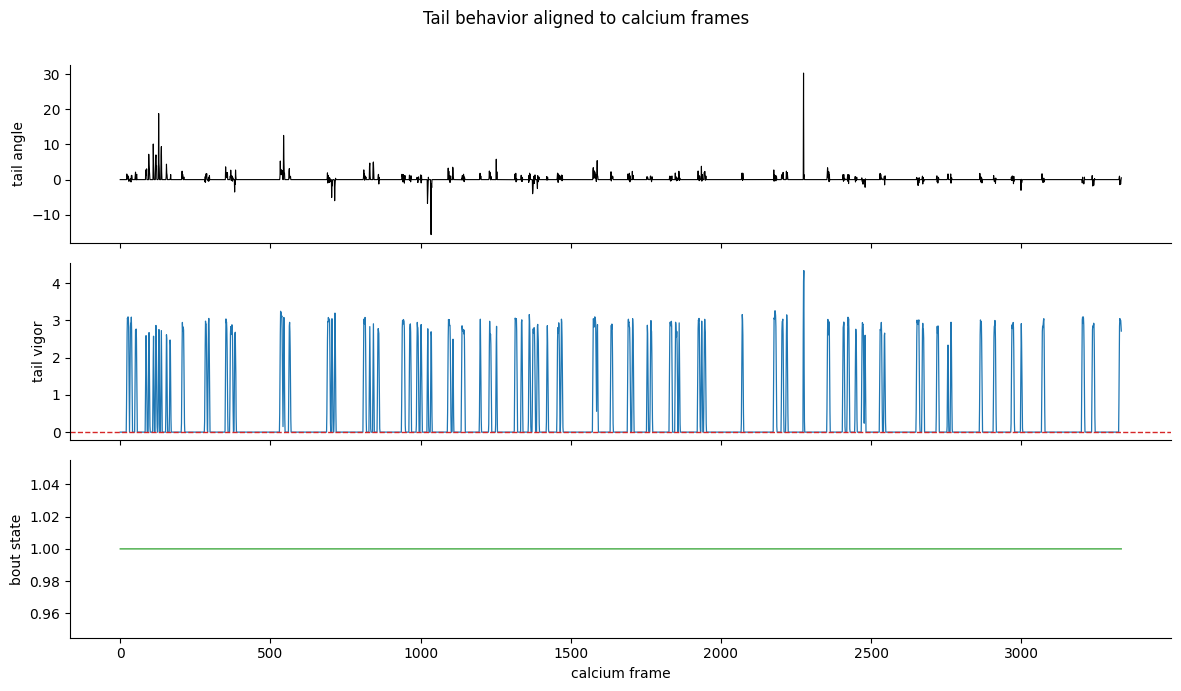

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
frames = np.arange(raw.shape[0])
axes[0].plot(frames, targets.angle, color="black", lw=0.8)
axes[0].set_ylabel("tail angle")
axes[1].plot(frames, targets.vigor, color="tab:blue", lw=0.9)
axes[1].axhline(targets.bout_threshold, color="tab:red", ls="--", lw=1)
axes[1].set_ylabel("tail vigor")
axes[2].plot(frames, targets.bout_state, color="tab:green", lw=0.9)
axes[2].set_ylabel("bout state")
axes[2].set_xlabel("calcium frame")
fig.suptitle("Tail behavior aligned to calcium frames")
fig.tight_layout(rect=(0, 0, 1, 0.97))
target_plot_path = CHAINED_FIGURE_DIR / f"tail_behavior_alignment_{dataset.data_name}.png"
fig.savefig(target_plot_path, dpi=PLOT_DPI, bbox_inches="tight")
print(f"Saved target alignment plot: {target_plot_path.relative_to(PROJECT_ROOT)}")


## Chained Supervised Behavior Decoding

This section decodes behavior from the raw traces and from the cleaned traces produced by `cluster_clean_reconstruct.ipynb`. These outputs are stage-dependent and descriptive.

In [7]:
trace_preservation = summarize_trace_preservation(variants, reference_name="raw")
trace_preservation_path = CHAINED_OUTPUT_DIR / "full_recording_trace_preservation.csv"
trace_preservation.to_csv(trace_preservation_path, index=False)
print(f"Saved trace preservation metrics: {trace_preservation_path.relative_to(PROJECT_ROOT)}")
trace_preservation


Saved trace preservation metrics: outputs/behavior_decoding/v2a-RSNs/220210_F1_run6/full_recording_trace_preservation.csv


,variant,path,reference,n_frames,n_neurons,global_pearson,neuron_pearson_mean,neuron_pearson_median,neuron_pearson_q25,neuron_pearson_q75,rmse_mean,nrmse_mean,mean_abs_delta,variance_ratio_median,variance_ratio_q25,variance_ratio_q75
0,raw,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220210_F1_run6/220210_F1_F1_run6_cells_fluore...,raw,3334,1085,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
1,fastica/keep_top_01/cleaned_fastica_220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/fastica/incremental/...,raw,3334,1085,0.944110,0.566064,0.578165,0.493034,0.646165,3.300224,0.813905,2.230281,0.334275,0.243083,0.417529
2,fastica/keep_top_02/cleaned_fastica_220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/fastica/incremental/...,raw,3334,1085,0.964418,0.695962,0.716830,0.613913,0.795498,2.717239,0.698556,1.860650,0.513846,0.376889,0.632816
3,fastica/keep_top_03/cleaned_fastica_220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/fastica/incremental/...,raw,3334,1085,0.970873,0.748061,0.763986,0.672371,0.839408,2.476969,0.644069,1.732647,0.583674,0.452083,0.704606
4,fastica/keep_top_04/cleaned_fastica_220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/fastica/incremental/...,raw,3334,1085,0.978655,0.814723,0.827745,0.755685,0.887541,2.135772,0.562024,1.533258,0.685162,0.571059,0.787729
5,fastica/keep_top_05/cleaned_fastica_220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/fastica/incremental/...,raw,3334,1085,0.988166,0.884653,0.897867,0.841793,0.934650,1.648716,0.449080,1.257770,0.806164,0.708615,0.873571
6,fastica/keep_top_06/cleaned_fastica_220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/fastica/incremental/...,raw,3334,1085,0.993810,0.943033,0.947961,0.923199,0.966020,1.189977,0.322360,0.895189,0.898629,0.852297,0.933194
7,infomax/keep_top_01/cleaned_infomax_220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/infomax/incremental/...,raw,3334,1085,0.980348,0.743264,0.770233,0.629821,0.883169,2.192760,0.623082,1.678516,0.593258,0.396675,0.779988
8,infomax/keep_top_02/cleaned_infomax_220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/infomax/incremental/...,raw,3334,1085,0.987283,0.814627,0.842088,0.729002,0.930479,1.813858,0.535040,1.426892,0.709113,0.531443,0.865792
9,infomax/keep_top_03/cleaned_infomax_220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220210_F1_run6/infomax/incremental/...,raw,3334,1085,0.989590,0.837548,0.864664,0.763676,0.944302,1.661505,0.500466,1.312948,0.747644,0.583201,0.891706


In [8]:
if RUN_CHAINED_BEHAVIOR_DECODING:
    common_kwargs = dict(
        variants=variants,
        lags=DECODER_LAGS,
        target_shift=TARGET_SHIFT,
        n_splits=BEHAVIOR_N_SPLITS,
        gap=BEHAVIOR_GAP,
        ridge_alpha=RIDGE_ALPHA,
        include_transfer=True,
        include_null=True,
        null_block_size=NULL_BLOCK_SIZE,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )
    vigor_result = run_decoding_experiment(
        target=targets.vigor,
        target_name="tail_vigor",
        task="regression",
        **common_kwargs,
    )
    bout_result = run_decoding_experiment(
        target=targets.bout_state,
        target_name="bout_state",
        task="classification",
        **common_kwargs,
    )

    supervised_metrics = pd.concat([vigor_result.metrics, bout_result.metrics], ignore_index=True)
    supervised_summary = pd.concat([vigor_result.summary, bout_result.summary], ignore_index=True)
    supervised_predictions = pd.concat([vigor_result.predictions, bout_result.predictions], ignore_index=True)
else:
    supervised_metrics = pd.DataFrame()
    supervised_summary = pd.DataFrame()
    supervised_predictions = pd.DataFrame()

supervised_summary.head(40)


,target,task,comparison,train_version,test_version,r2_mean,r2_std,pearson_mean,pearson_std,spearman_mean,...,rmse_mean,rmse_std,nrmse_mean,nrmse_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std
0,tail_vigor,regression,null_within,fastica/keep_top_01/cleaned_fastica_220210_F1_run6_fluorescence,fastica/keep_top_01/cleaned_fastica_220210_F1_run6_fluorescence,-0.823058,0.459297,0.018716,0.149756,0.019826,...,1.251533,0.227927,1.341684,0.169345,NaN,NaN,NaN,NaN,NaN,NaN
1,tail_vigor,regression,null_within,fastica/keep_top_02/cleaned_fastica_220210_F1_run6_fluorescence,fastica/keep_top_02/cleaned_fastica_220210_F1_run6_fluorescence,-1.188745,0.655323,0.028418,0.107425,0.025172,...,1.369688,0.279696,1.466896,0.214947,NaN,NaN,NaN,NaN,NaN,NaN
2,tail_vigor,regression,null_within,fastica/keep_top_03/cleaned_fastica_220210_F1_run6_fluorescence,fastica/keep_top_03/cleaned_fastica_220210_F1_run6_fluorescence,-1.583126,0.778945,0.011049,0.101237,0.009255,...,1.487430,0.308322,1.592675,0.241118,NaN,NaN,NaN,NaN,NaN,NaN
3,tail_vigor,regression,null_within,fastica/keep_top_04/cleaned_fastica_220210_F1_run6_fluorescence,fastica/keep_top_04/cleaned_fastica_220210_F1_run6_fluorescence,-2.150520,0.848375,-0.016894,0.112216,-0.021663,...,1.639693,0.289917,1.762055,0.238962,NaN,NaN,NaN,NaN,NaN,NaN
4,tail_vigor,regression,null_within,fastica/keep_top_05/cleaned_fastica_220210_F1_run6_fluorescence,fastica/keep_top_05/cleaned_fastica_220210_F1_run6_fluorescence,-3.216649,1.329455,0.011292,0.098710,0.017547,...,1.891677,0.346518,2.034687,0.309635,NaN,NaN,NaN,NaN,NaN,NaN
5,tail_vigor,regression,null_within,fastica/keep_top_06/cleaned_fastica_220210_F1_run6_fluorescence,fastica/keep_top_06/cleaned_fastica_220210_F1_run6_fluorescence,-6.299643,3.423334,0.007580,0.086575,0.008121,...,2.465902,0.604365,2.651541,0.579842,NaN,NaN,NaN,NaN,NaN,NaN
6,tail_vigor,regression,null_within,infomax/keep_top_01/cleaned_infomax_220210_F1_run6_fluorescence,infomax/keep_top_01/cleaned_infomax_220210_F1_run6_fluorescence,-0.134068,0.082304,0.058670,0.050969,0.053258,...,0.988231,0.085657,1.064373,0.038382,NaN,NaN,NaN,NaN,NaN,NaN
7,tail_vigor,regression,null_within,infomax/keep_top_02/cleaned_infomax_220210_F1_run6_fluorescence,infomax/keep_top_02/cleaned_infomax_220210_F1_run6_fluorescence,-0.851839,0.676447,0.012066,0.066542,-0.020109,...,1.254529,0.273605,1.344635,0.233978,NaN,NaN,NaN,NaN,NaN,NaN
8,tail_vigor,regression,null_within,infomax/keep_top_03/cleaned_infomax_220210_F1_run6_fluorescence,infomax/keep_top_03/cleaned_infomax_220210_F1_run6_fluorescence,-1.204746,0.579564,-0.004910,0.045500,-0.032116,...,1.369638,0.215159,1.474241,0.197991,NaN,NaN,NaN,NaN,NaN,NaN
9,tail_vigor,regression,null_within,infomax/keep_top_04/cleaned_infomax_220210_F1_run6_fluorescence,infomax/keep_top_04/cleaned_infomax_220210_F1_run6_fluorescence,-1.754031,0.547617,0.001336,0.053178,-0.001858,...,1.535367,0.202461,1.652661,0.168610,NaN,NaN,NaN,NaN,NaN,NaN


,method,tail_vigor_within_pearson,tail_vigor_within_pearson_preservation_pct,tail_vigor_transfer_pearson,tail_vigor_transfer_pearson_preservation_pct,bout_state_within_balanced_accuracy,bout_state_within_balanced_accuracy_preservation_pct,bout_state_transfer_balanced_accuracy,bout_state_transfer_balanced_accuracy_preservation_pct,behavioral_preservation_index,neuron_pearson_median,nrmse_mean,variance_ratio_median,mean_abs_delta,recommendation_label
0,raw,0.300112,100.000000,0.300112,100.000000,NaN,NaN,NaN,NaN,100.000000,1.000000,0.000000,1.000000,0.000000,raw reference
1,infomax/keep_top_01/cleaned_infomax_220210_F1_run6_fluorescence,0.537049,181.278458,0.442768,148.936373,NaN,NaN,NaN,NaN,165.107416,0.770233,0.623082,0.593258,1.678516,best preserved
2,infomax/keep_top_02/cleaned_infomax_220210_F1_run6_fluorescence,0.438234,147.381048,0.391631,131.394401,NaN,NaN,NaN,NaN,139.387725,0.842088,0.535040,0.709113,1.426892,acceptable
3,infomax/keep_top_03/cleaned_infomax_220210_F1_run6_fluorescence,0.417931,140.416261,0.375924,126.006235,NaN,NaN,NaN,NaN,133.211248,0.864664,0.500466,0.747644,1.312948,acceptable
4,infomax/keep_top_04/cleaned_infomax_220210_F1_run6_fluorescence,0.374185,125.409955,0.346039,115.754638,NaN,NaN,NaN,NaN,120.582297,0.927035,0.420178,0.859394,1.080924,acceptable
5,fastica/keep_top_03/cleaned_fastica_220210_F1_run6_fluorescence,0.303945,101.314705,0.320545,107.009434,NaN,NaN,NaN,NaN,104.162070,0.763986,0.644069,0.583674,1.732647,acceptable
6,infomax/keep_top_05/cleaned_infomax_220210_F1_run6_fluorescence,0.295589,98.448348,0.324202,108.263895,NaN,NaN,NaN,NaN,103.356121,0.952081,0.349502,0.906458,0.896937,acceptable
7,infomax/keep_top_06/cleaned_infomax_220210_F1_run6_fluorescence,0.289375,96.316784,0.312215,104.151769,NaN,NaN,NaN,NaN,100.234277,0.975113,0.257890,0.950846,0.662789,acceptable
8,fastica/keep_top_02/cleaned_fastica_220210_F1_run6_fluorescence,0.310845,103.681645,0.289902,96.497429,NaN,NaN,NaN,NaN,100.089537,0.716830,0.698556,0.513846,1.860650,acceptable
9,fastica/keep_top_05/cleaned_fastica_220210_F1_run6_fluorescence,0.262958,87.254859,0.304146,101.383648,NaN,NaN,NaN,NaN,94.319253,0.897867,0.449080,0.806164,1.257770,acceptable


,target,task,method,selection_id,clusters_kept,score_metric,score,delta_vs_prev,delta_vs_raw,variant
0,bout_state,classification,fastica,keep_top_01,1.0,balanced_accuracy_mean,NaN,NaN,NaN,fastica/keep_top_01/cleaned_fastica_220210_F1_run6_fluorescence
1,bout_state,classification,fastica,keep_top_02,2.0,balanced_accuracy_mean,NaN,NaN,NaN,fastica/keep_top_02/cleaned_fastica_220210_F1_run6_fluorescence
2,bout_state,classification,fastica,keep_top_03,3.0,balanced_accuracy_mean,NaN,NaN,NaN,fastica/keep_top_03/cleaned_fastica_220210_F1_run6_fluorescence
3,bout_state,classification,fastica,keep_top_04,4.0,balanced_accuracy_mean,NaN,NaN,NaN,fastica/keep_top_04/cleaned_fastica_220210_F1_run6_fluorescence
4,bout_state,classification,fastica,keep_top_05,5.0,balanced_accuracy_mean,NaN,NaN,NaN,fastica/keep_top_05/cleaned_fastica_220210_F1_run6_fluorescence
5,bout_state,classification,fastica,keep_top_06,6.0,balanced_accuracy_mean,NaN,NaN,NaN,fastica/keep_top_06/cleaned_fastica_220210_F1_run6_fluorescence
6,bout_state,classification,infomax,keep_top_01,1.0,balanced_accuracy_mean,NaN,NaN,NaN,infomax/keep_top_01/cleaned_infomax_220210_F1_run6_fluorescence
7,bout_state,classification,infomax,keep_top_02,2.0,balanced_accuracy_mean,NaN,NaN,NaN,infomax/keep_top_02/cleaned_infomax_220210_F1_run6_fluorescence
8,bout_state,classification,infomax,keep_top_03,3.0,balanced_accuracy_mean,NaN,NaN,NaN,infomax/keep_top_03/cleaned_infomax_220210_F1_run6_fluorescence
9,bout_state,classification,infomax,keep_top_04,4.0,balanced_accuracy_mean,NaN,NaN,NaN,infomax/keep_top_04/cleaned_infomax_220210_F1_run6_fluorescence


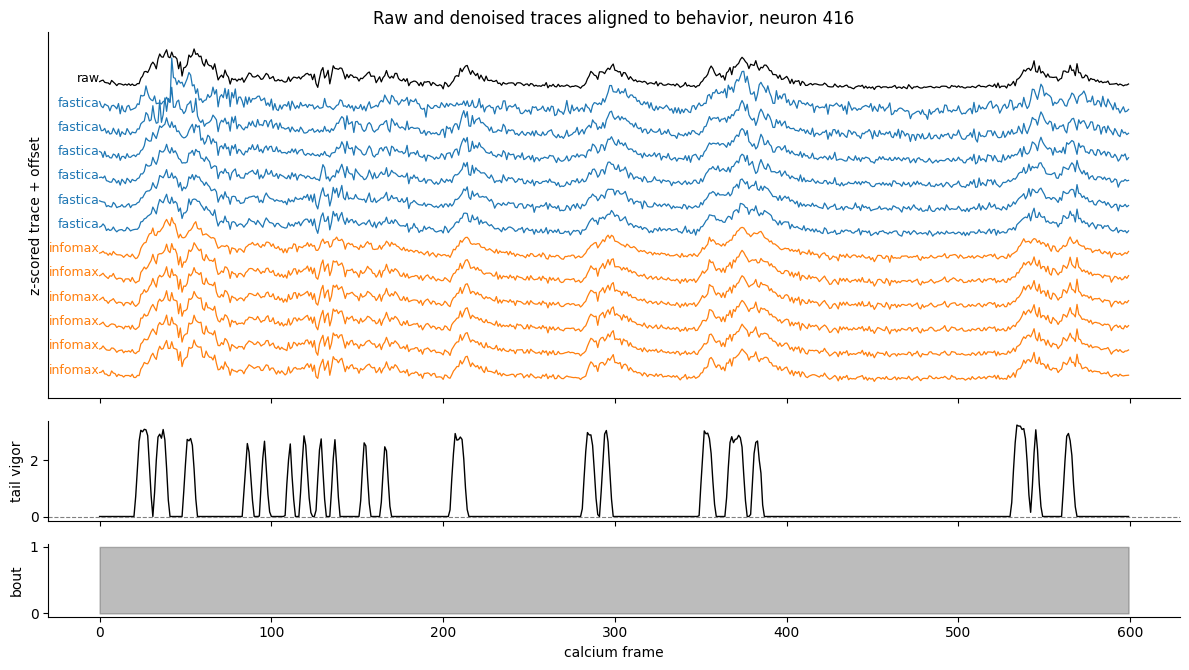

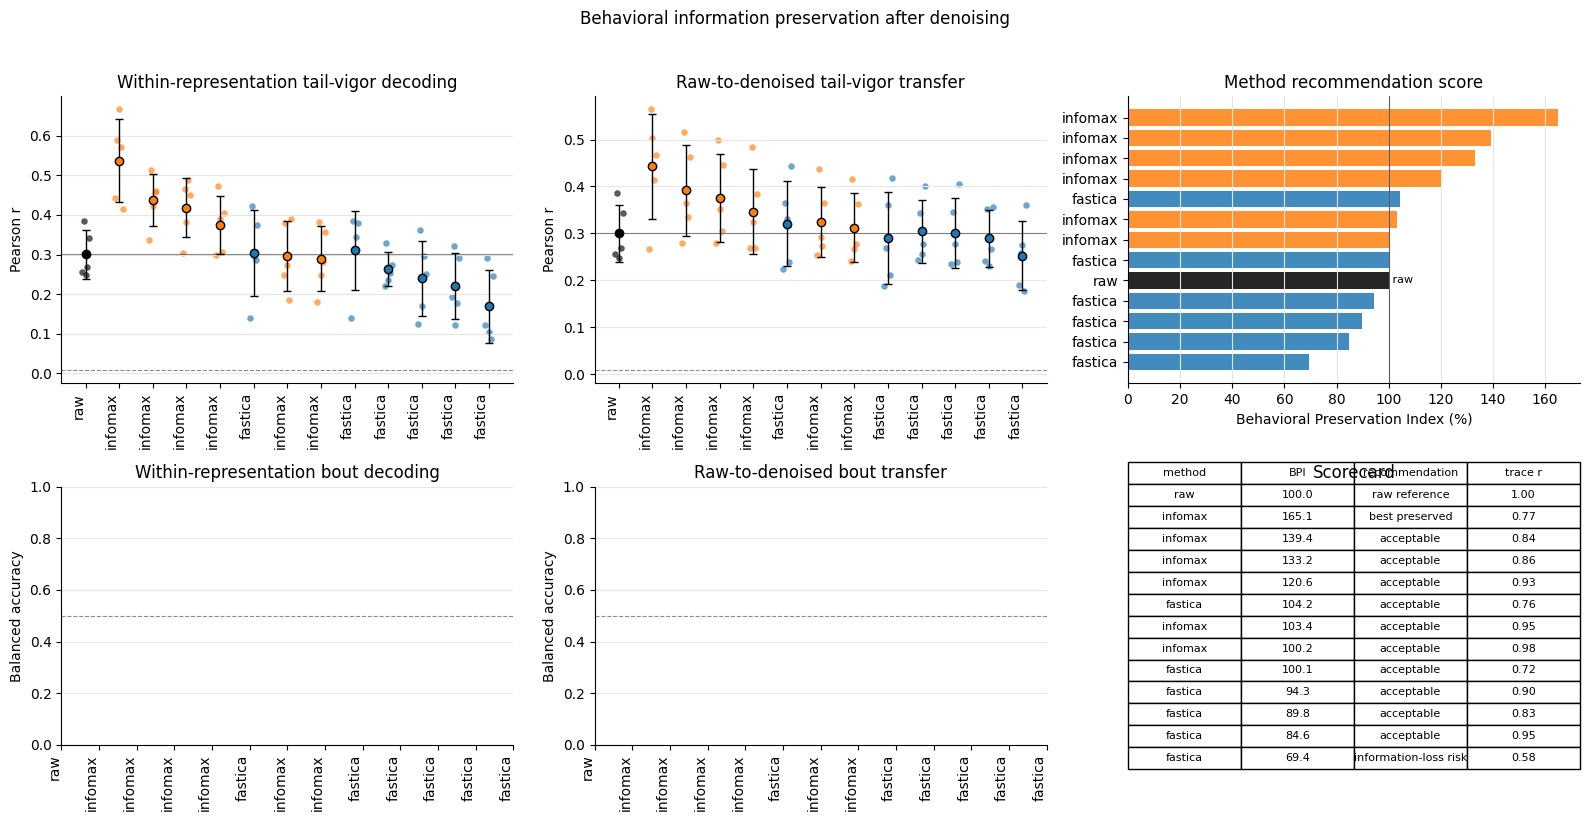

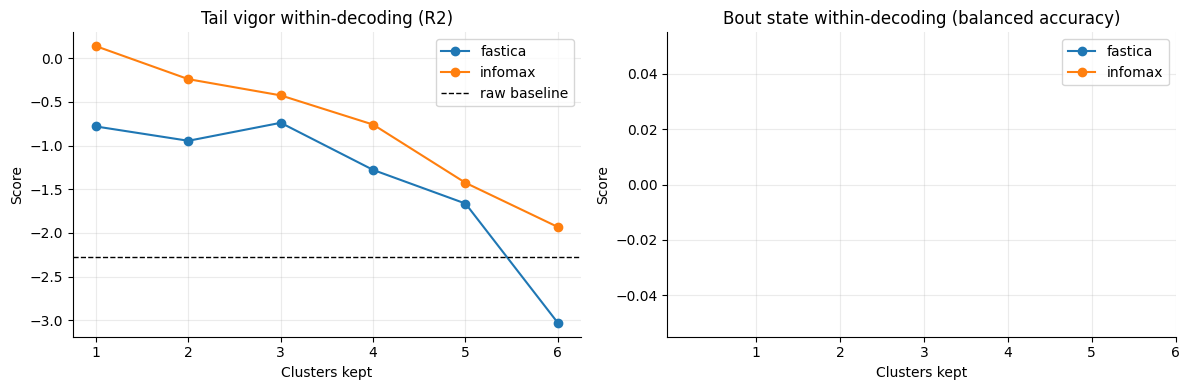

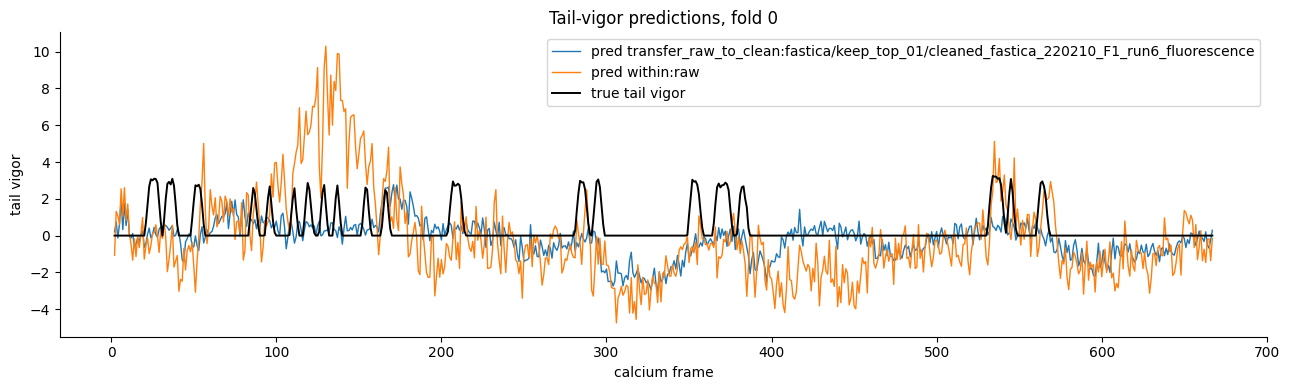

In [9]:
if RUN_CHAINED_BEHAVIOR_DECODING:
    trace_evidence_fig, _ = plot_behavior_trace_evidence(
        variants,
        targets,
        window_size=600,
    )
    preservation_fig, _, behavior_scorecard = plot_behavior_preservation_summary(
        supervised_metrics,
        supervised_summary,
        variants=variants,
    )

    variant_meta = trace_table[["variant", "method", "selection_id", "clusters_kept", "is_incremental"]].copy()
    within_summary = supervised_summary[supervised_summary["comparison"] == "within"].copy().rename(
        columns={"test_version": "variant"}
    )
    within_summary = within_summary.merge(variant_meta, on="variant", how="left")
    within_summary["score"] = np.where(
        within_summary["task"] == "regression",
        within_summary["r2_mean"],
        within_summary["balanced_accuracy_mean"],
    )
    within_summary["score_metric"] = np.where(
        within_summary["task"] == "regression",
        "r2_mean",
        "balanced_accuracy_mean",
    )
    raw_baseline = within_summary[within_summary["variant"] == "raw"][["target", "task", "score"]].rename(
        columns={"score": "raw_score"}
    )

    cluster_progress_table = (
        within_summary[within_summary["is_incremental"]]
        .merge(raw_baseline, on=["target", "task"], how="left")
        .sort_values(["target", "task", "method", "clusters_kept"])
        .copy()
    )
    if not cluster_progress_table.empty:
        cluster_progress_table["delta_vs_prev"] = cluster_progress_table.groupby(
            ["target", "task", "method"]
        )["score"].diff()
        cluster_progress_table["delta_vs_raw"] = cluster_progress_table["score"] - cluster_progress_table["raw_score"]
        cluster_progress_table = cluster_progress_table[
            [
                "target",
                "task",
                "method",
                "selection_id",
                "clusters_kept",
                "score_metric",
                "score",
                "delta_vs_prev",
                "delta_vs_raw",
                "variant",
            ]
        ].reset_index(drop=True)

        progress_plot_targets = [
            ("tail_vigor", "Tail vigor within-decoding (R2)"),
            ("bout_state", "Bout state within-decoding (balanced accuracy)"),
        ]
        cluster_progress_fig, axes = plt.subplots(
            1,
            len(progress_plot_targets),
            figsize=(6 * len(progress_plot_targets), 4),
        )
        axes = np.atleast_1d(axes)
        for ax, (target_name, title) in zip(axes, progress_plot_targets):
            target_rows = cluster_progress_table[cluster_progress_table["target"] == target_name]
            for method_name, group in target_rows.groupby("method"):
                group = group.sort_values("clusters_kept")
                ax.plot(
                    group["clusters_kept"],
                    group["score"],
                    marker="o",
                    lw=1.5,
                    label=method_name,
                )
            task_name = "regression" if target_name == "tail_vigor" else "classification"
            raw_row = raw_baseline[(raw_baseline["target"] == target_name) & (raw_baseline["task"] == task_name)]
            if not raw_row.empty and np.isfinite(raw_row["raw_score"].iloc[0]):
                ax.axhline(
                    raw_row["raw_score"].iloc[0],
                    color="black",
                    linestyle="--",
                    linewidth=1,
                    label="raw baseline",
                )
            if not target_rows.empty:
                ax.set_xticks(sorted(target_rows["clusters_kept"].dropna().astype(int).unique()))
            ax.set_title(title)
            ax.set_xlabel("Clusters kept")
            ax.set_ylabel("Score")
            ax.grid(alpha=0.25)
            ax.legend(loc="best")
        cluster_progress_fig.tight_layout()
    else:
        cluster_progress_fig = None
        print("No incremental keep-top variants detected for supervised behavior progression.")

    example_version = variants[1].name if len(variants) > 1 else "raw"
    fold = 0
    prediction_plot_df = supervised_predictions.query(
        "target == 'tail_vigor' and fold == @fold and "
        "((comparison == 'within' and test_version == 'raw') or "
        "(comparison == 'transfer_raw_to_clean' and test_version == @example_version))"
    ).copy()
    if prediction_plot_df.empty:
        prediction_trace_fig = None
    else:
        prediction_trace_fig, ax = plt.subplots(figsize=(13, 4))
        for label, group in prediction_plot_df.groupby(["comparison", "test_version"]):
            group = group.sort_values("time_index")
            ax.plot(group["time_index"], group["y_pred"], lw=1, label=f"pred {label[0]}:{label[1]}")
        truth = prediction_plot_df.drop_duplicates("time_index").sort_values("time_index")
        ax.plot(truth["time_index"], truth["y_true"], color="black", lw=1.4, label="true tail vigor")
        ax.set_title(f"Tail-vigor predictions, fold {fold}")
        ax.set_xlabel("calcium frame")
        ax.set_ylabel("tail vigor")
        ax.legend(loc="best")
        prediction_trace_fig.tight_layout()

    supervised_metrics.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_fold_metrics.csv", index=False)
    supervised_summary.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_summary.csv", index=False)
    supervised_predictions.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_predictions.csv", index=False)
    behavior_scorecard.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_scorecard.csv", index=False)
    behavior_scorecard.to_csv(CHAINED_OUTPUT_DIR / "behavior_preservation_scorecard.csv", index=False)
    if "cluster_progress_table" in globals() and isinstance(cluster_progress_table, pd.DataFrame):
        cluster_progress_table.to_csv(CHAINED_OUTPUT_DIR / "cluster_progression_summary.csv", index=False)
    trace_evidence_fig.savefig(
        CHAINED_FIGURE_DIR / f"full_recording_trace_behavior_evidence_{dataset.data_name}.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    trace_evidence_fig.savefig(
        CHAINED_FIGURE_DIR / "paper_trace_behavior_evidence.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    preservation_fig.savefig(
        CHAINED_FIGURE_DIR / f"full_recording_behavior_preservation_summary_{dataset.data_name}.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    preservation_fig.savefig(
        CHAINED_FIGURE_DIR / "paper_behavior_preservation_summary.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    if cluster_progress_fig is not None:
        cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
        cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "paper_cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
    if prediction_trace_fig is not None:
        prediction_trace_fig.savefig(
            CHAINED_FIGURE_DIR / "tail_vigor_prediction_trace.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
    display(behavior_scorecard)
    if "cluster_progress_table" in globals():
        display(cluster_progress_table)


## Chained Causal-State Behavior Decoding

This uses the same raw and cluster-cleaned trace variants loaded above.

In [10]:
if RUN_CHAINED_BEHAVIOR_DECODING:
    causal_config = CausalStateConfig(
        window=CAUSAL_WINDOW,
        target_shifts=CAUSAL_TARGET_SHIFTS,
        latent_dim=CAUSAL_LATENT_DIM,
        n_splits=CAUSAL_N_SPLITS,
        gap=CAUSAL_GAP,
        ridge_alpha=CAUSAL_RIDGE_ALPHA,
        bout_quantile=BOUT_QUANTILE,
        random_state=RANDOM_STATE,
    )
    causal_result = fit_causal_state_model(
        variants=variants,
        targets=targets,
        config=causal_config,
    )
    causal_summary = (
        causal_result.fold_metrics.groupby(["variant", "target_shift"], dropna=False)
        .agg(
            dynamic_mse_normalized_mean=("dynamic_mse_normalized", "mean"),
            dynamic_improvement_vs_persistence_mean=("dynamic_improvement_vs_persistence", "mean"),
            angle_pearson_mean=("angle_pearson", "mean"),
            vigor_pearson_mean=("vigor_pearson", "mean"),
            bout_balanced_accuracy_mean=("bout_balanced_accuracy", "mean"),
        )
        .reset_index()
    )
else:
    causal_result = None
    causal_summary = pd.DataFrame()

causal_summary.head(40)


,variant,target_shift,dynamic_mse_normalized_mean,dynamic_improvement_vs_persistence_mean,angle_pearson_mean,vigor_pearson_mean,bout_balanced_accuracy_mean
0,fastica/keep_top_01/cleaned_fastica_220210_F1_run6_fluorescence,0,0.011054,0.000122,0.057633,0.212366,NaN
1,fastica/keep_top_02/cleaned_fastica_220210_F1_run6_fluorescence,0,0.009219,-0.000856,0.115183,0.304435,NaN
2,fastica/keep_top_03/cleaned_fastica_220210_F1_run6_fluorescence,0,0.008561,0.000557,0.133713,0.322826,NaN
3,fastica/keep_top_04/cleaned_fastica_220210_F1_run6_fluorescence,0,0.007805,-0.000544,0.140257,0.336080,NaN
4,fastica/keep_top_05/cleaned_fastica_220210_F1_run6_fluorescence,0,0.006752,-0.001708,0.154384,0.338685,NaN
5,fastica/keep_top_06/cleaned_fastica_220210_F1_run6_fluorescence,0,0.006016,-0.001806,0.153856,0.347929,NaN
6,infomax/keep_top_01/cleaned_infomax_220210_F1_run6_fluorescence,0,0.006633,-0.005616,0.156077,0.343740,NaN
7,infomax/keep_top_02/cleaned_infomax_220210_F1_run6_fluorescence,0,0.006666,-0.002579,0.149601,0.339093,NaN
8,infomax/keep_top_03/cleaned_infomax_220210_F1_run6_fluorescence,0,0.006554,-0.002786,0.150357,0.339671,NaN
9,infomax/keep_top_04/cleaned_infomax_220210_F1_run6_fluorescence,0,0.006227,-0.002641,0.151222,0.343174,NaN


Saved causal diagnostics plot: outputs/behavior_decoding/v2a-RSNs/220210_F1_run6/figures/full_recording_causal_diagnostics_220210_F1_run6_fluorescence.png


,variant,target_shift,corr_to_angle_next,corr_to_vigor_next,corr_to_bout_next,residual_vigor_corr,residual_bout_corr,variant_label
0,fastica/keep_top_01/cleaned_fastica_220210_F1_run6_fluorescence,0,0.012034,0.105391,NaN,0.166258,NaN,FastICA-k1
1,fastica/keep_top_02/cleaned_fastica_220210_F1_run6_fluorescence,0,0.015181,0.199095,NaN,0.200103,NaN,FastICA-k2
2,fastica/keep_top_03/cleaned_fastica_220210_F1_run6_fluorescence,0,0.006753,0.219516,NaN,0.231194,NaN,FastICA-k3
3,fastica/keep_top_04/cleaned_fastica_220210_F1_run6_fluorescence,0,0.013076,0.180183,NaN,0.253151,NaN,FastICA-k4
4,fastica/keep_top_05/cleaned_fastica_220210_F1_run6_fluorescence,0,0.024372,0.256673,NaN,0.274817,NaN,FastICA-k5
5,fastica/keep_top_06/cleaned_fastica_220210_F1_run6_fluorescence,0,0.022303,0.262146,NaN,0.321418,NaN,FastICA-k6
6,infomax/keep_top_01/cleaned_infomax_220210_F1_run6_fluorescence,0,0.007638,0.258673,NaN,0.356504,NaN,Infomax-k1
7,infomax/keep_top_02/cleaned_infomax_220210_F1_run6_fluorescence,0,-0.001128,0.250148,NaN,0.342586,NaN,Infomax-k2
8,infomax/keep_top_03/cleaned_infomax_220210_F1_run6_fluorescence,0,-0.003351,0.248108,NaN,0.341417,NaN,Infomax-k3
9,infomax/keep_top_04/cleaned_infomax_220210_F1_run6_fluorescence,0,0.023137,0.257205,NaN,0.346588,NaN,Infomax-k4


,metric,method,selection_id,clusters_kept,target_shift,score,delta_vs_prev,delta_vs_raw,variant
0,bout_balanced_accuracy,fastica,keep_top_01,1.0,0,NaN,NaN,NaN,fastica/keep_top_01/cleaned_fastica_220210_F1_run6_fluorescence
1,bout_balanced_accuracy,fastica,keep_top_02,2.0,0,NaN,NaN,NaN,fastica/keep_top_02/cleaned_fastica_220210_F1_run6_fluorescence
2,bout_balanced_accuracy,fastica,keep_top_03,3.0,0,NaN,NaN,NaN,fastica/keep_top_03/cleaned_fastica_220210_F1_run6_fluorescence
3,bout_balanced_accuracy,fastica,keep_top_04,4.0,0,NaN,NaN,NaN,fastica/keep_top_04/cleaned_fastica_220210_F1_run6_fluorescence
4,bout_balanced_accuracy,fastica,keep_top_05,5.0,0,NaN,NaN,NaN,fastica/keep_top_05/cleaned_fastica_220210_F1_run6_fluorescence
5,bout_balanced_accuracy,fastica,keep_top_06,6.0,0,NaN,NaN,NaN,fastica/keep_top_06/cleaned_fastica_220210_F1_run6_fluorescence
6,bout_balanced_accuracy,infomax,keep_top_01,1.0,0,NaN,NaN,NaN,infomax/keep_top_01/cleaned_infomax_220210_F1_run6_fluorescence
7,bout_balanced_accuracy,infomax,keep_top_02,2.0,0,NaN,NaN,NaN,infomax/keep_top_02/cleaned_infomax_220210_F1_run6_fluorescence
8,bout_balanced_accuracy,infomax,keep_top_03,3.0,0,NaN,NaN,NaN,infomax/keep_top_03/cleaned_infomax_220210_F1_run6_fluorescence
9,bout_balanced_accuracy,infomax,keep_top_04,4.0,0,NaN,NaN,NaN,infomax/keep_top_04/cleaned_infomax_220210_F1_run6_fluorescence


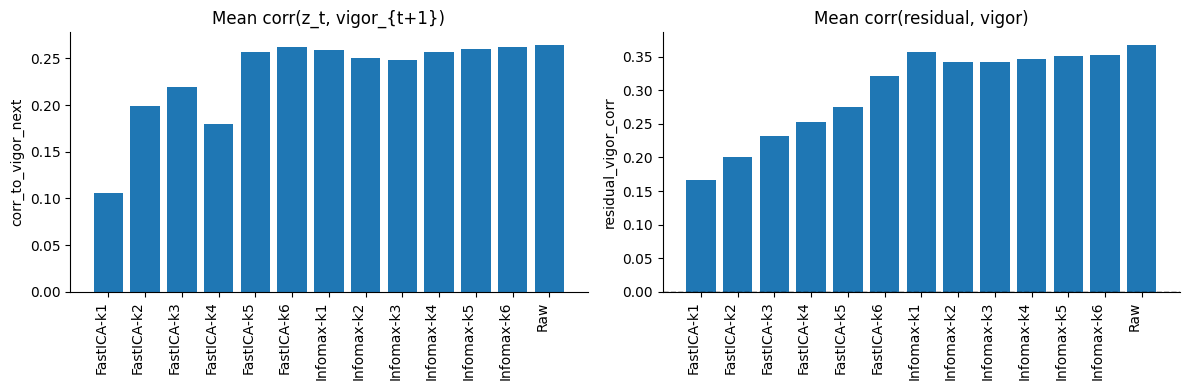

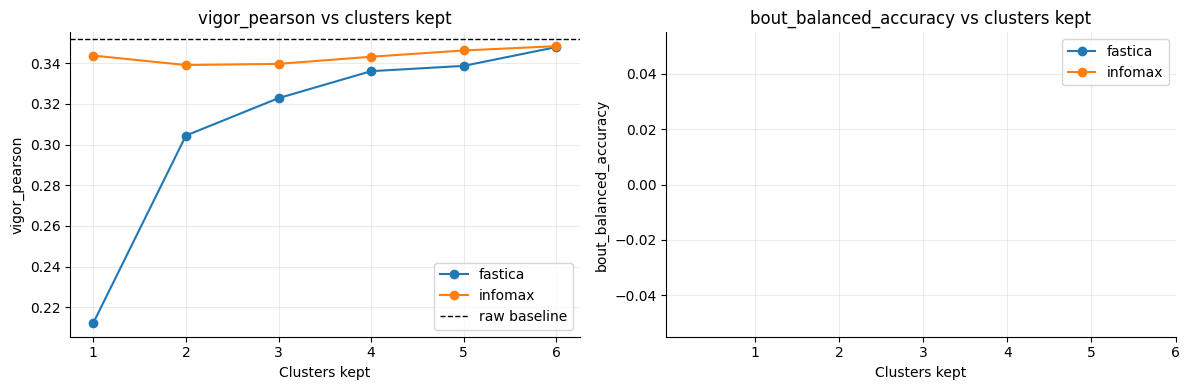

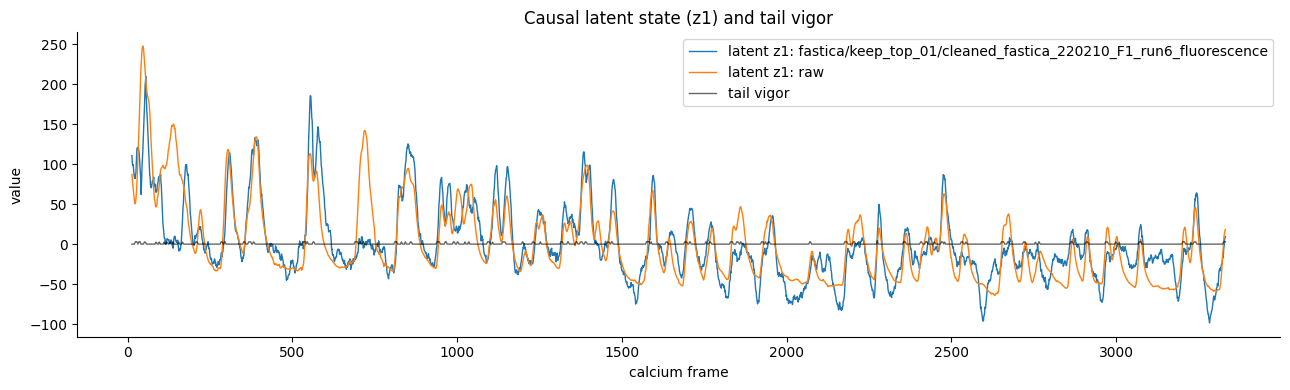

In [11]:
if RUN_CHAINED_BEHAVIOR_DECODING and causal_result is not None:
    causal_result.fold_metrics.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_fold_metrics.csv", index=False)
    causal_summary.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_summary.csv", index=False)
    causal_result.embeddings.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_embeddings.csv", index=False)
    causal_result.graph_metrics.to_csv(
        CHAINED_OUTPUT_DIR / "full_recording_causal_latent_behavior_correlations.csv",
        index=False,
    )
    causal_result.residual_tests.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_residual_tests.csv", index=False)

    graph_summary = causal_result.graph_metrics.groupby(["variant", "target_shift"], as_index=False)[
        ["corr_to_angle_next", "corr_to_vigor_next", "corr_to_bout_next"]
    ].mean()
    resid_summary = causal_result.residual_tests.groupby(["variant", "target_shift"], as_index=False)[
        ["residual_vigor_corr", "residual_bout_corr"]
    ].mean()
    causal_diag = graph_summary.merge(resid_summary, on=["variant", "target_shift"], how="left")

    def _short_variant_label(name: str) -> str:
        if name == "raw":
            return "Raw"
        parts = name.split("/")
        method = parts[0] if parts else name
        method_label = {
            "fastica": "FastICA",
            "infomax": "Infomax",
        }.get(method, method.replace("_", " ").title().replace(" ", ""))
        selection_id = _selection_id_from_variant(name)
        clusters_kept = _clusters_kept_from_selection(selection_id)
        if pd.notna(clusters_kept):
            return f"{method_label}-k{int(clusters_kept)}"
        return method_label

    causal_diag["variant_label"] = causal_diag["variant"].map(_short_variant_label)
    causal_diag.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_diagnostics_summary.csv", index=False)

    causal_diag_fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(causal_diag))
    labels = causal_diag["variant_label"].astype(str).tolist()
    axes[0].bar(x, causal_diag["corr_to_vigor_next"].to_numpy(dtype=float))
    axes[0].set_title("Mean corr(z_t, vigor_{t+1})")
    axes[0].set_ylabel("corr_to_vigor_next")
    axes[1].bar(x, causal_diag["residual_vigor_corr"].to_numpy(dtype=float))
    axes[1].axhline(0.0, linestyle="--", linewidth=1, color="black")
    axes[1].set_title("Mean corr(residual, vigor)")
    axes[1].set_ylabel("residual_vigor_corr")
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=90, ha="right")
        ax.set_xlabel("")
    causal_diag_fig.tight_layout()
    causal_diag_plot_path = CHAINED_FIGURE_DIR / f"full_recording_causal_diagnostics_{dataset.data_name}.png"
    causal_diag_fig.savefig(causal_diag_plot_path, dpi=PLOT_DPI, bbox_inches="tight")
    causal_diag_fig.savefig(CHAINED_FIGURE_DIR / "paper_causal_diagnostics_summary.png", dpi=PLOT_DPI, bbox_inches="tight")
    print(f"Saved causal diagnostics plot: {causal_diag_plot_path.relative_to(PROJECT_ROOT)}")

    variant_meta = trace_table[["variant", "method", "selection_id", "clusters_kept", "is_incremental"]].copy()
    causal_summary_with_meta = causal_summary.merge(variant_meta, on="variant", how="left")
    causal_metric_specs = [
        ("vigor_pearson_mean", "vigor_pearson"),
        ("bout_balanced_accuracy_mean", "bout_balanced_accuracy"),
    ]
    progress_frames = []
    for metric_column, metric_name in causal_metric_specs:
        metric_df = causal_summary_with_meta[
            [
                "variant",
                "target_shift",
                "method",
                "selection_id",
                "clusters_kept",
                "is_incremental",
                metric_column,
            ]
        ].copy()
        metric_df = metric_df.rename(columns={metric_column: "score"})
        metric_df["metric"] = metric_name
        raw_scores = metric_df[metric_df["variant"] == "raw"][["target_shift", "score"]].rename(
            columns={"score": "raw_score"}
        )
        metric_df = metric_df[metric_df["is_incremental"]].merge(raw_scores, on="target_shift", how="left")
        progress_frames.append(metric_df)

    causal_cluster_progress = pd.concat(progress_frames, ignore_index=True) if progress_frames else pd.DataFrame()
    if not causal_cluster_progress.empty:
        causal_cluster_progress = causal_cluster_progress.sort_values(
            ["metric", "method", "target_shift", "clusters_kept"]
        )
        causal_cluster_progress["delta_vs_prev"] = causal_cluster_progress.groupby(
            ["metric", "method", "target_shift"]
        )["score"].diff()
        causal_cluster_progress["delta_vs_raw"] = causal_cluster_progress["score"] - causal_cluster_progress["raw_score"]
        causal_cluster_progress = causal_cluster_progress[
            [
                "metric",
                "method",
                "selection_id",
                "clusters_kept",
                "target_shift",
                "score",
                "delta_vs_prev",
                "delta_vs_raw",
                "variant",
            ]
        ].reset_index(drop=True)

        causal_cluster_progress_fig, axes = plt.subplots(
            1,
            len(causal_metric_specs),
            figsize=(6 * len(causal_metric_specs), 4),
        )
        axes = np.atleast_1d(axes)
        baseline_shift = CAUSAL_TARGET_SHIFTS[0] if CAUSAL_TARGET_SHIFTS else 0
        for ax, (metric_column, metric_name) in zip(axes, causal_metric_specs):
            metric_rows = causal_cluster_progress[causal_cluster_progress["metric"] == metric_name]
            for method_name, group in metric_rows.groupby("method"):
                group = group.sort_values("clusters_kept")
                ax.plot(
                    group["clusters_kept"],
                    group["score"],
                    marker="o",
                    lw=1.5,
                    label=method_name,
                )
            baseline_rows = causal_summary_with_meta[
                (causal_summary_with_meta["variant"] == "raw")
                & (causal_summary_with_meta["target_shift"] == baseline_shift)
            ]
            if not baseline_rows.empty:
                baseline_value = baseline_rows.iloc[0][metric_column]
                if np.isfinite(baseline_value):
                    ax.axhline(
                        baseline_value,
                        color="black",
                        linestyle="--",
                        linewidth=1,
                        label="raw baseline",
                    )
            if not metric_rows.empty:
                ax.set_xticks(sorted(metric_rows["clusters_kept"].dropna().astype(int).unique()))
            ax.set_title(f"{metric_name} vs clusters kept")
            ax.set_xlabel("Clusters kept")
            ax.set_ylabel(metric_name)
            ax.grid(alpha=0.25)
            ax.legend(loc="best")
        causal_cluster_progress_fig.tight_layout()
        causal_cluster_progress.to_csv(CHAINED_OUTPUT_DIR / "causal_cluster_progression_summary.csv", index=False)
        causal_cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "causal_cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
        causal_cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "paper_causal_cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
    else:
        causal_cluster_progress_fig = None
        print("No incremental keep-top variants detected for causal cluster progression.")

    embeddings = causal_result.embeddings.copy()
    example_version = variants[1].name if len(variants) > 1 else "raw"
    latent_plot_df = embeddings.query("variant in ['raw', @example_version]").sort_values("time_index")
    if latent_plot_df.empty:
        causal_latent_fig = None
    else:
        causal_latent_fig, ax = plt.subplots(figsize=(13, 4))
        for name, group in latent_plot_df.groupby("variant"):
            ax.plot(group["time_index"], group["z1"], lw=1, label=f"latent z1: {name}")
        truth = latent_plot_df.drop_duplicates("time_index").sort_values("time_index")
        ax.plot(truth["time_index"], truth["vigor"], color="black", lw=1.0, alpha=0.6, label="tail vigor")
        ax.set_title("Causal latent state (z1) and tail vigor")
        ax.set_xlabel("calcium frame")
        ax.set_ylabel("value")
        ax.legend(loc="best")
        causal_latent_fig.tight_layout()
        causal_latent_fig.savefig(
            CHAINED_FIGURE_DIR / "causal_latent_trace.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )

    display(causal_diag)
    if "causal_cluster_progress" in globals():
        display(causal_cluster_progress)


## Strict Fold-Local Evaluation

This section is optional in the notebook but should be used for primary paper claims. It does not reuse full-recording decompositions or cleaned traces; it refits preprocessing inside each training fold to prevent leakage.

In [12]:
strict_config_path = PROJECT_ROOT / "configs" / STRICT_CONFIG_NAME
strict_config = load_evaluation_config(strict_config_path, sample_rate_hz=float(dataset.sample_rate_hz))
print(f"Strict config: {strict_config_path.relative_to(PROJECT_ROOT)}")
print(f"Strict output directory: {STRICT_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")


Strict config: configs/evaluation.example.json
Strict output directory: outputs/evaluation/v2a-RSNs/220210_F1_run6


In [13]:
if RUN_STRICT_EVALUATION:
    strict_paths = run_dataset_evaluation(
        DATASET_KEY,
        project_root=PROJECT_ROOT,
        config_path=strict_config_path,
        output_root=STRICT_OUTPUT_ROOT,
        output_data_name_override=OUTPUT_DATA_NAME,
    )
else:
    strict_paths = {
        "trace_metrics": STRICT_OUTPUT_DIR / "strict_trace_preservation_metrics.csv",
        "behavior_metrics": STRICT_OUTPUT_DIR / "strict_behavior_fold_metrics.csv",
        "behavior_predictions": STRICT_OUTPUT_DIR / "strict_behavior_predictions.csv",
        "behavior_uncertainty": STRICT_OUTPUT_DIR / "strict_behavior_block_uncertainty.csv",
        "causal_metrics": STRICT_OUTPUT_DIR / "strict_causal_fold_metrics.csv",
        "causal_embeddings": STRICT_OUTPUT_DIR / "strict_causal_oof_embeddings.csv",
        "causal_latent_correlations": STRICT_OUTPUT_DIR / "strict_causal_oof_latent_behavior_correlations.csv",
        "leakage_audit": STRICT_OUTPUT_DIR / "leakage_audit.csv",
        "component_selections": STRICT_OUTPUT_DIR / "component_selections.csv",
        "cluster_stability": STRICT_OUTPUT_DIR / "cluster_stability.csv",
        "cluster_stability_assignments": STRICT_OUTPUT_DIR / "cluster_stability_assignments.csv",
        "variant_metadata": STRICT_OUTPUT_DIR / "variant_metadata.csv",
        "temporal_diagnostics": STRICT_OUTPUT_DIR / "temporal_dependence_diagnostics.csv",
        "bpi_component_scores": STRICT_OUTPUT_DIR / "bpi_component_scores.csv",
        "bpi_ablation": STRICT_OUTPUT_DIR / "bpi_ablation.csv",
        "run_manifest": STRICT_OUTPUT_DIR / "run_manifest.json",
    }

pd.DataFrame(
    {
        "artifact": strict_paths.keys(),
        "path": strict_paths.values(),
        "exists": [path.exists() for path in strict_paths.values()],
    }
)


KeyboardInterrupt: 

In [ ]:
def read_metric_table(path):
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


strict_tables = {
    name: read_metric_table(path)
    for name, path in strict_paths.items()
    if path.suffix == ".csv" and path.exists()
}
strict_manifest = (
    json.loads(strict_paths["run_manifest"].read_text(encoding="utf-8"))
    if strict_paths["run_manifest"].exists()
    else {}
)

artifact_overview = pd.DataFrame(
    [
        {"artifact": name, "rows": len(table), "columns": len(table.columns)}
        for name, table in strict_tables.items()
    ]
).sort_values("artifact")
artifact_overview


In [ ]:
if strict_tables:
    trace_summary = (
        strict_tables["trace_metrics"]
        .groupby(["family", "variant"], dropna=False)[
            [
                "global_pearson",
                "neuron_pearson_median",
                "nrmse_mean",
                "retained_energy_fraction",
                "spectral_power_retention",
                "low_frequency_power_fraction",
            ]
        ]
        .mean()
        .reset_index()
        .sort_values("nrmse_mean")
    )
    behavior_summary = (
        strict_tables["behavior_metrics"]
        .query("comparison in ['within', 'transfer_raw_to_clean']")
        .groupby(["target", "comparison", "test_version"], dropna=False)[
            ["pearson", "nrmse", "balanced_accuracy", "roc_auc"]
        ]
        .mean()
        .reset_index()
    )
    causal_summary_strict = (
        strict_tables["causal_metrics"]
        .groupby(["transition_model", "variant"], dropna=False)[
            [
                "dynamic_mse_normalized",
                "dynamic_improvement_vs_persistence",
                "angle_pearson",
                "vigor_pearson",
                "bout_balanced_accuracy",
            ]
        ]
        .mean()
        .reset_index()
        .sort_values("dynamic_mse_normalized")
    )
    display(trace_summary.head(40))
    display(behavior_summary.head(60))
    display(causal_summary_strict.head(50))


In [ ]:
if strict_tables and strict_manifest:
    print(f"All leakage checks passed: {strict_tables['leakage_audit']['leakage_free'].all()}")
    print(f"All BSS fits converged: {strict_manifest['all_bss_fits_converged']}")
    print(f"All causal fits converged: {strict_manifest['all_causal_fits_converged']}")
    print(f"Strict manifest: {strict_paths['run_manifest'].relative_to(PROJECT_ROOT)}")
    print(f"Chained behavior outputs: {CHAINED_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

    display(strict_tables["behavior_uncertainty"].head(30))
    display(strict_tables["bpi_ablation"].head(30))
    display(strict_tables["temporal_diagnostics"].head(30))
    display(strict_tables["cluster_stability"].head(30))
